Mounted at /content/drive


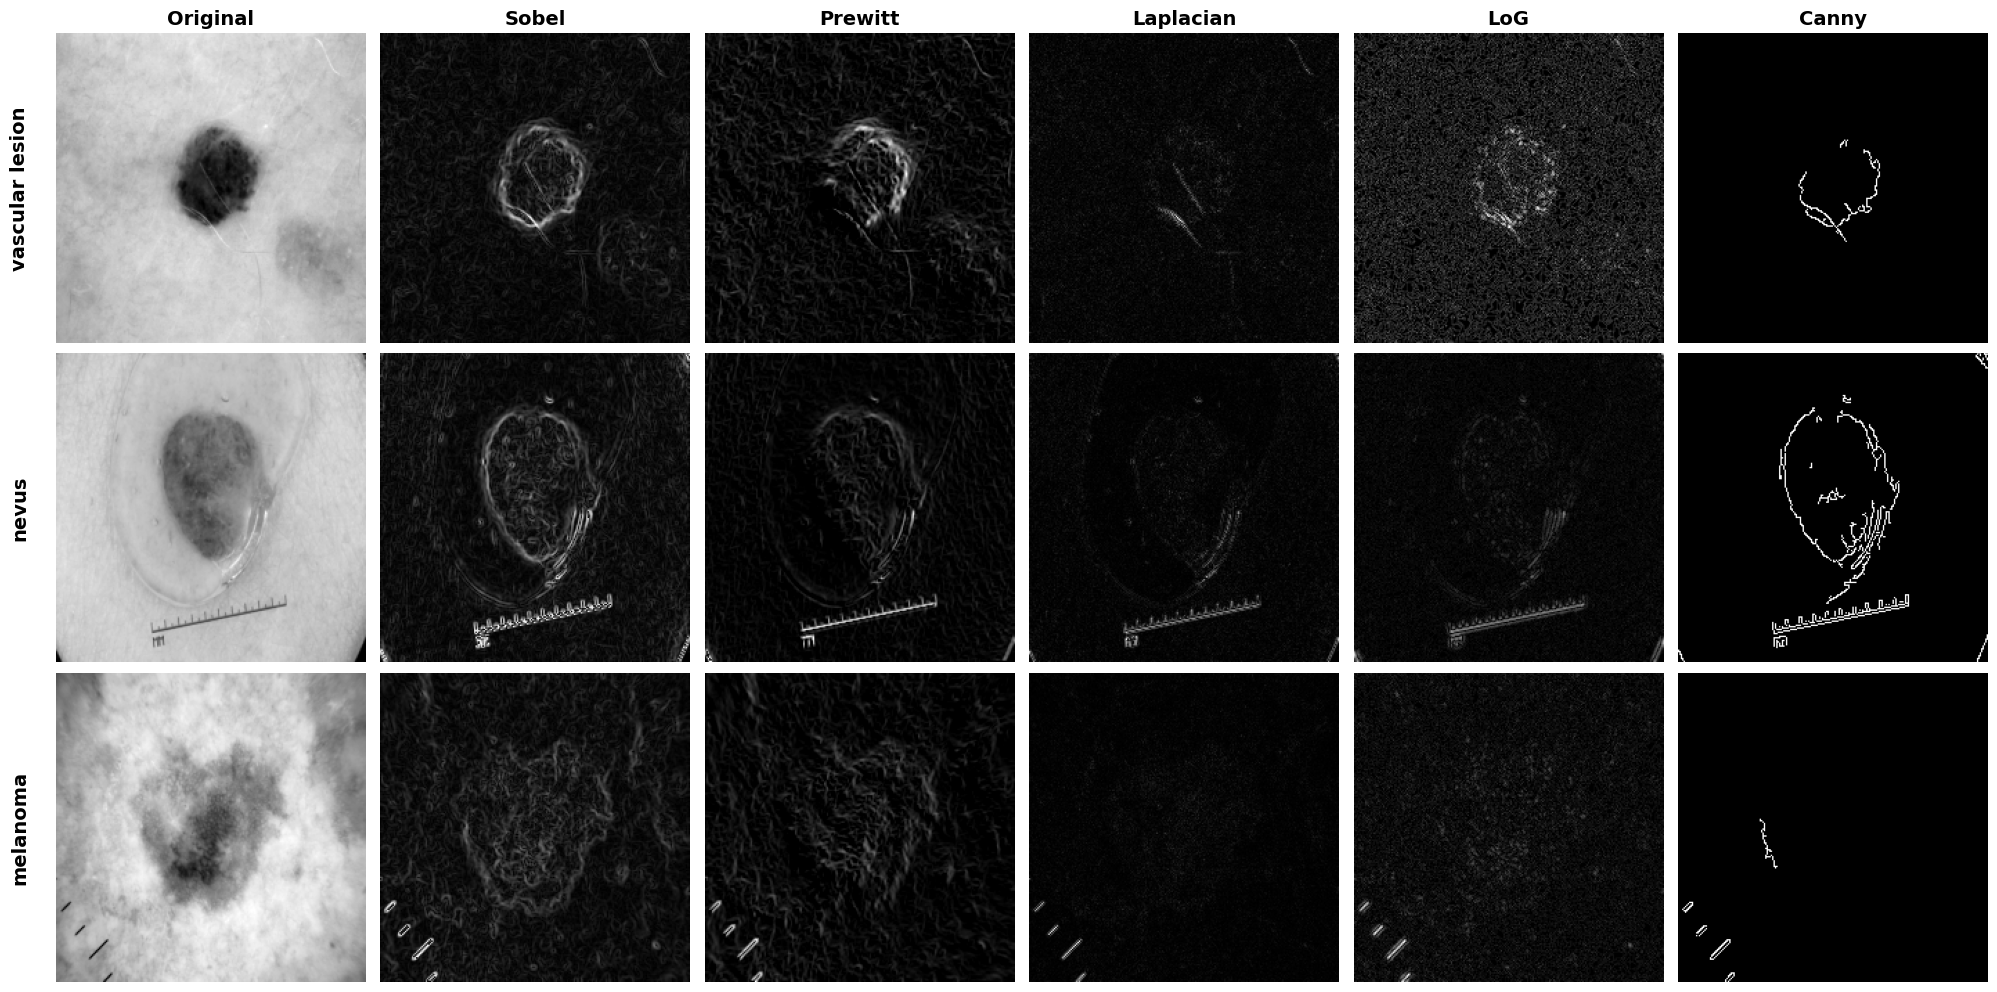

In [2]:
import os
import cv2
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from google.colab import drive

# 1. Mount Google Drive and Extract Dataset
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/Intro to CV/skin_cancer.zip" /content/
!unzip -q -o /content/skin_cancer.zip -d /content/dataset/

# Dynamically locate the Train directory
base_dir = '/content/dataset'
for root, dirs, files in os.walk(base_dir):
    if 'Train' in dirs:
        base_dir = root
        break

# Use a basic transform to load the raw images for edge detection
transform = transforms.Compose([
    transforms.Resize((224, 224))
])
train_data = datasets.ImageFolder(os.path.join(base_dir, 'Train'), transform=transform)
class_names = train_data.classes

# 2. Define Edge Detection Functions
def apply_edge_detectors(img_pil):
    # Convert PIL Image to grayscale numpy array
    img = np.array(img_pil)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # A. First-Order Edge Detectors
    # Sobel gradient magnitude (combining G_x and G_y for the final plot)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobelx, sobely)
    sobel_mag = np.uint8(np.absolute(sobel_mag))

    # Prewitt
    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewittx = cv2.filter2D(gray, -1, kernelx)
    prewitty = cv2.filter2D(gray, -1, kernely)
    prewitt_mag = cv2.magnitude(np.float32(prewittx), np.float32(prewitty))
    prewitt_mag = np.uint8(np.absolute(prewitt_mag))

    # B. Second-Order Edge Detectors
    # Laplacian
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))

    # Laplacian of Gaussian (LoG)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    log = cv2.Laplacian(blur, cv2.CV_64F)
    log = np.uint8(np.absolute(log))

    # C. Multi-Stage Edge Detector
    # Canny
    canny = cv2.Canny(gray, 50, 150)

    return gray, sobel_mag, prewitt_mag, laplacian, log, canny

# 3. Select 3 random images from 3 different classes
selected_classes = random.sample(range(len(class_names)), 3)
selected_images = []

for cls_idx in selected_classes:
    class_indices = [i for i, target in enumerate(train_data.targets) if target == cls_idx]
    random_img_idx = random.choice(class_indices)
    img_pil, _ = train_data[random_img_idx]
    selected_images.append((img_pil, class_names[cls_idx]))

# 4. Generate the Required Figure for Task 1
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
column_titles = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]

for row, (img_pil, cls_name) in enumerate(selected_images):
    edges = apply_edge_detectors(img_pil)

    for col, edge_img in enumerate(edges):
        ax = axes[row, col]
        ax.imshow(edge_img, cmap='gray')
        ax.axis('off')

        # Add column titles to the top row
        if row == 0:
            ax.set_title(column_titles[col], fontsize=14, fontweight='bold')

        # Add class names to the first column
        if col == 0:
            ax.text(-20, 112, cls_name, fontsize=14, fontweight='bold',
                    ha='right', va='center', rotation=90)

plt.tight_layout()
plt.show()

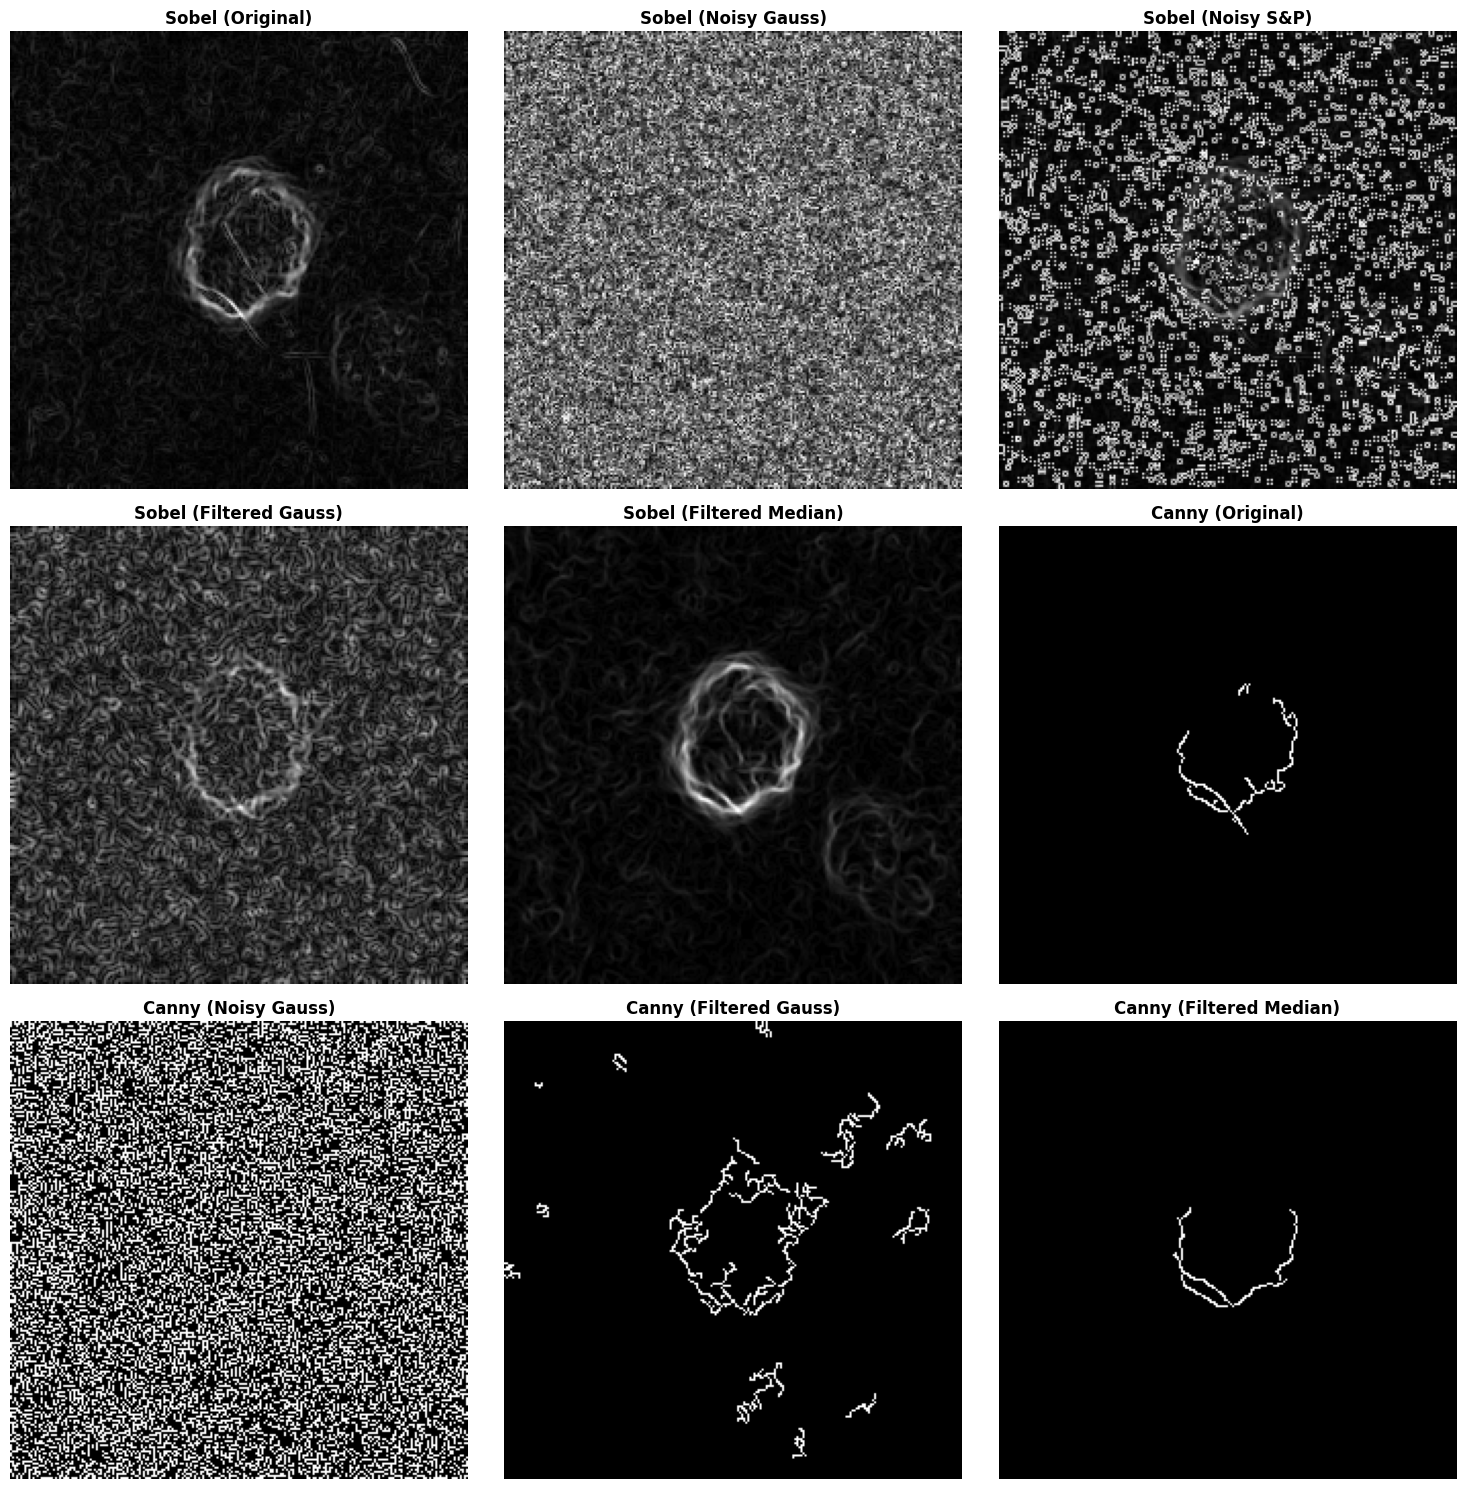

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Noise Generation Functions
def add_gaussian_noise(image, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, image.shape)
    noisy = np.clip(image + gauss, 0, 255).astype(np.uint8)
    return noisy

def add_salt_and_pepper_noise(image, prob=0.05):
    noisy = np.copy(image)
    # Salt
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255
    # Pepper
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

# 2. Extract one image from the previous task for analysis
img_pil, cls_name = selected_images[0]
original = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2GRAY)

# 3. Create Noisy and Filtered Versions
noisy_gauss = add_gaussian_noise(original)
noisy_sp = add_salt_and_pepper_noise(original)

filtered_gauss = cv2.GaussianBlur(noisy_gauss, (5, 5), 0)
filtered_median = cv2.medianBlur(noisy_sp, 5)

# 4. Generate Edge Maps for Table 1 Observations
# Sobel (Magnitude)
def sobel_mag(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.uint8(np.absolute(cv2.magnitude(sx, sy)))

edges = {
    "Sobel (Original)": sobel_mag(original),
    "Sobel (Noisy Gauss)": sobel_mag(noisy_gauss),
    "Sobel (Noisy S&P)": sobel_mag(noisy_sp),
    "Sobel (Filtered Gauss)": sobel_mag(filtered_gauss),
    "Sobel (Filtered Median)": sobel_mag(filtered_median),
    "Canny (Original)": cv2.Canny(original, 50, 150),
    "Canny (Noisy Gauss)": cv2.Canny(noisy_gauss, 50, 150),
    "Canny (Filtered Gauss)": cv2.Canny(filtered_gauss, 50, 150),
    "Canny (Filtered Median)": cv2.Canny(filtered_median, 50, 150)
}

# 5. Plot Results
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, (title, img) in enumerate(edges.items()):
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

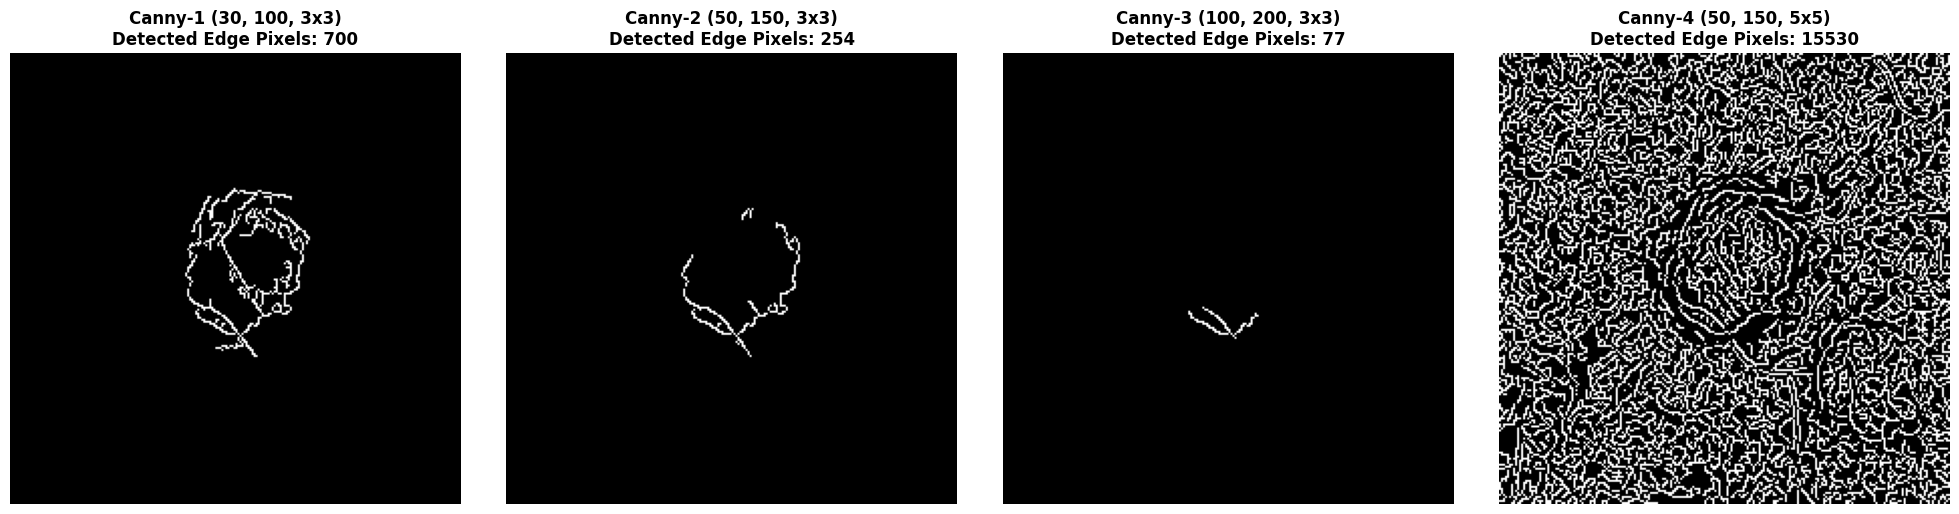

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Canny configurations based on Task 3 requirements
# Canny uses 'apertureSize' to define the size of the underlying Sobel kernel (default is 3)
canny_configs = {
    "Canny-1 (30, 100, 3x3)": cv2.Canny(original, 30, 100, apertureSize=3),
    "Canny-2 (50, 150, 3x3)": cv2.Canny(original, 50, 150, apertureSize=3),
    "Canny-3 (100, 200, 3x3)": cv2.Canny(original, 100, 200, apertureSize=3),
    "Canny-4 (50, 150, 5x5)": cv2.Canny(original, 50, 150, apertureSize=5)
}

# 2. Plot the results and calculate the number of edge pixels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (title, edge_img) in zip(axes, canny_configs.items()):
    # Count non-zero pixels (white pixels = detected edges)
    edge_count = np.count_nonzero(edge_img)

    ax.imshow(edge_img, cmap='gray')
    ax.set_title(f"{title}\nDetected Edge Pixels: {edge_count}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
import cv2
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = '/content/dataset'
for root, dirs, files in os.walk(base_dir):
    if 'Train' in dirs:
        base_dir = root
        break

NUM_EPOCHS = 1 # Set to 1 for faster Colab execution

# --- 1. Custom Transforms ---
class AverageFilterTransform:
    def __call__(self, img):
        cv_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        blurred = cv2.blur(cv_img, (5, 5))
        return Image.fromarray(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))

class CannyEdgeTransform:
    def __call__(self, img):
        gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        edges_3ch = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(edges_3ch)

norm_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_dict = {
    "Set A (Raw Images)": norm_transform,
    "Set B (Filtered - Average)": transforms.Compose([AverageFilterTransform(), norm_transform]),
    "Set C (Edge Maps - Canny)": transforms.Compose([CannyEdgeTransform(), norm_transform])
}

cnn_models_dict = {
    "CNN Model 1 (EfficientNet-B0)": "efficientnet",
    "CNN Model 2 (ResNet18)": "resnet"
}

# Dictionaries to store data for Task 5 and Task 6
results_table_3 = {}
task6_preds = {}
task6_labels = {}

# --- 2. Unified Training & Evaluation Loop ---
for set_name, current_transform in transforms_dict.items():
    print(f"\n{'='*60}\n--- Processing {set_name} ---")
    train_data = datasets.ImageFolder(os.path.join(base_dir, 'Train'), transform=current_transform)
    test_data = datasets.ImageFolder(os.path.join(base_dir, 'Test'), transform=current_transform)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
    num_classes = len(train_data.classes)
    class_names = train_data.classes

    # Train CNNs
    for model_name, model_type in cnn_models_dict.items():
        print(f"Training {model_name}...")
        if model_type == "efficientnet":
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        else:
            model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            model.fc = nn.Linear(model.fc.in_features, num_classes)

        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        model.train()
        start_train = time.time()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(inputs.to(device)), labels.to(device))
            loss.backward()
            optimizer.step()
        train_time = time.time() - start_train

        model.eval()
        all_preds, all_labels = [], []
        start_infer = time.time()
        with torch.no_grad():
            for inputs, labels in test_loader:
                preds = torch.max(model(inputs.to(device)), 1)[1]
                all_labels.extend(labels.numpy())
                all_preds.extend(preds.cpu().numpy())
        infer_time = ((time.time() - start_infer) / len(test_data)) * 1000

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        print(f"  > Acc: {acc*100:.2f}% | Prec: {prec*100:.2f}% | Rec: {rec*100:.2f}% | F1: {f1*100:.2f}%")

        results_table_3[f"{model_name} - {set_name}"] = {"Acc": acc, "Prec": prec, "Rec": rec, "F1": f1}

        # Save predictions of the primary CNN for Task 6 matrices
        if model_type == "efficientnet":
            task6_preds[set_name] = all_preds
            task6_labels[set_name] = all_labels

    # Classical ML (Only required for Set C in Table 3)
    if "Canny" in set_name:
        print(f"\n--- Extracting Deep Features for Classical ML on {set_name} ---")
        fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        fe.fc = nn.Identity()
        fe = fe.to(device).eval()

        def extract(loader):
            feats, lbls = [], []
            with torch.no_grad():
                for inp, lbl in loader:
                    feats.append(fe(inp.to(device)).cpu().numpy())
                    lbls.append(lbl.numpy())
            return np.vstack(feats), np.concatenate(lbls)

        X_train, y_train = extract(train_loader)
        X_test, y_test = extract(test_loader)

        classical_models = {
            "SVM": SVC(kernel='linear', max_iter=500),
            "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
            "KNN": KNeighborsClassifier(n_jobs=-1)
        }

        for c_name, c_model in classical_models.items():
            print(f"Training {c_name}...")
            c_model.fit(X_train, y_train)
            c_preds = c_model.predict(X_test)
            acc = accuracy_score(y_test, c_preds)
            prec, rec, f1, _ = precision_recall_fscore_support(y_test, c_preds, average='macro', zero_division=0)
            print(f"  > Acc: {acc*100:.2f}% | Prec: {prec*100:.2f}% | Rec: {rec*100:.2f}% | F1: {f1*100:.2f}%")
            results_table_3[f"{c_name} - Set C"] = {"Acc": acc, "Prec": prec, "Rec": rec, "F1": f1}

print("\nAll models successfully trained and evaluated.")


--- Processing Set A (Raw Images) ---
Training CNN Model 1 (EfficientNet-B0)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s] 


  > Acc: 38.14% | Prec: 28.99% | Rec: 40.28% | F1: 28.98%
Training CNN Model 2 (ResNet18)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


  > Acc: 47.46% | Prec: 54.13% | Rec: 47.92% | F1: 42.97%

--- Processing Set B (Filtered - Average) ---
Training CNN Model 1 (EfficientNet-B0)...
  > Acc: 45.76% | Prec: 35.30% | Rec: 46.53% | F1: 35.15%
Training CNN Model 2 (ResNet18)...
  > Acc: 49.15% | Prec: 47.67% | Rec: 49.31% | F1: 44.58%

--- Processing Set C (Edge Maps - Canny) ---
Training CNN Model 1 (EfficientNet-B0)...
  > Acc: 20.34% | Prec: 10.33% | Rec: 16.67% | F1: 10.39%
Training CNN Model 2 (ResNet18)...
  > Acc: 29.66% | Prec: 22.76% | Rec: 27.31% | F1: 20.38%

--- Extracting Deep Features for Classical ML on Set C (Edge Maps - Canny) ---
Training SVM...


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  > Acc: 22.88% | Prec: 21.32% | Rec: 27.78% | F1: 22.04%
Training Random Forest...
  > Acc: 26.27% | Prec: 19.29% | Rec: 27.55% | F1: 21.47%
Training KNN...
  > Acc: 26.27% | Prec: 27.61% | Rec: 27.55% | F1: 24.81%

All models successfully trained and evaluated.


--- Task 6: Visual Comparison ---


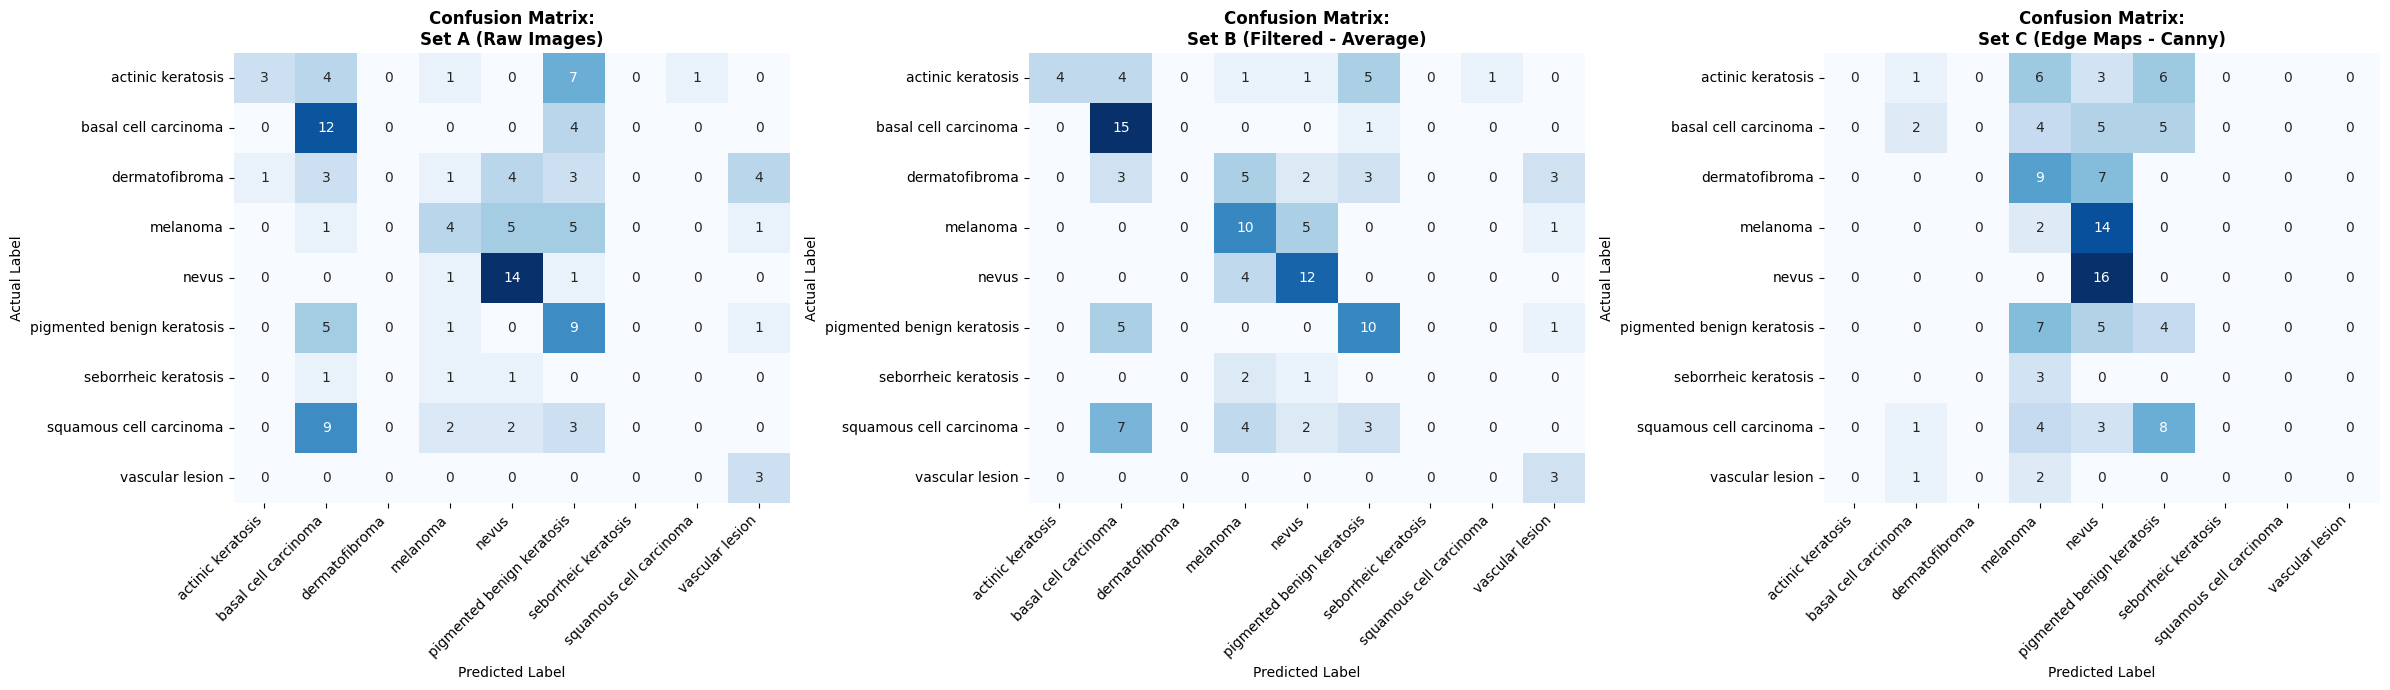

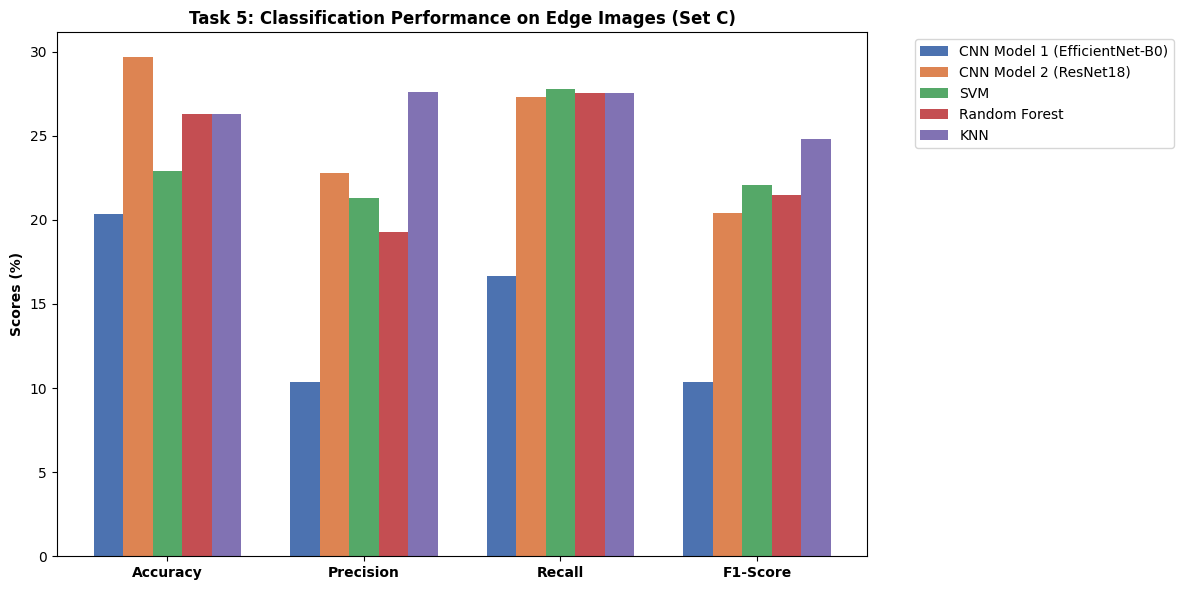

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("--- Task 6: Visual Comparison ---")

# 1. Plot 3 Confusion Matrices (Raw, Filtered, Edge)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
set_names = ["Set A (Raw Images)", "Set B (Filtered - Average)", "Set C (Edge Maps - Canny)"]

for ax, s_name in zip(axes, set_names):
    cm = confusion_matrix(task6_labels[s_name], task6_preds[s_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix:\n{s_name}", fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 2. Bar Chart for Set C Comparison (CNNs vs Classical ML)
models_to_plot = ["CNN Model 1 (EfficientNet-B0)", "CNN Model 2 (ResNet18)", "SVM", "Random Forest", "KNN"]
metrics = {m: [] for m in models_to_plot}

# Fetch metrics for the chart
for m in models_to_plot:
    key = f"{m} - Set C (Edge Maps - Canny)" if "CNN" in m else f"{m} - Set C"
    res = results_table_3.get(key, {"Acc":0, "Prec":0, "Rec":0, "F1":0})
    metrics[m] = [res["Acc"]*100, res["Prec"]*100, res["Rec"]*100, res["F1"]*100]

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for i, (m_name, m_scores) in enumerate(metrics.items()):
    offset = (i - 2) * width
    ax.bar(x + offset, m_scores, width, label=m_name, color=colors[i])

ax.set_ylabel('Scores (%)', fontweight='bold')
ax.set_title('Task 5: Classification Performance on Edge Images (Set C)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()